In [1]:
import torch
from torchinfo import summary
import matplotlib.pyplot as plt
import numpy as np

import sys
import os
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from prepare_dataset import get_dataloaders
from models import FSRCA
from utils import train_model, save_results, load_results, evaluate_model_on_sets
%load_ext autoreload
%autoreload 2

In [2]:
# variable definitions
factor = 4
device = torch.device("cuda")
model_name = "FSRCA"
criterion = torch.nn.L1Loss()
MODEL_CLASS = FSRCA
train_epochs, ft_epochs = 1000, 1000
train_lr, ft_lr = 1e-4, 1e-4

### Prepare model

In [5]:
weights, _ = load_results(model_name, 2)
model = MODEL_CLASS(upsample_factor=factor)
model.load_state_dict(weights, strict=False)
for param in model.parameters():
    param.requires_grad = False
for p in model.deconv.parameters():
    p.requires_grad = True

### Train

In [6]:
train_loader, val_loader = get_dataloaders(factor, n_workers_train=0, n_workers_val=0)
print(summary(model, input_size=(1, 1, 33, 33), device=device.type))

Layer (type:depth-idx)                                  Output Shape              Param #
FSRCA                                                   [1, 1, 132, 132]          --
├─Sequential: 1-1                                       [1, 56, 33, 33]           --
│    └─Conv2d: 2-1                                      [1, 56, 33, 33]           (1,456)
│    └─PReLU: 2-2                                       [1, 56, 33, 33]           (56)
├─Sequential: 1-2                                       [1, 12, 33, 33]           --
│    └─Conv2d: 2-3                                      [1, 12, 33, 33]           (684)
│    └─PReLU: 2-4                                       [1, 12, 33, 33]           (12)
├─RIR: 1-3                                              [1, 12, 33, 33]           --
│    └─Sequential: 2-5                                  [1, 12, 33, 33]           --
│    │    └─RCAB: 3-1                                   [1, 12, 33, 33]           (2,653)
│    │    └─RCAB: 3-2                      

In [7]:
train_loss, val_loss, psnr_list = train_model(model, train_loader, val_loader, factor, num_epochs=train_epochs, lr=train_lr, criterion=criterion)
save_results(model, train_loss, val_loss, psnr_list, model_name, factor)

Epoch 1/1000 - Training: 100%|██████████| 78/78 [00:55<00:00,  1.41it/s]


[Epoch 1] Train Loss: 0.093882
[Epoch 1] Validation Loss: 0.047043, PSNR: 24.22


Epoch 2/1000 - Training: 100%|██████████| 78/78 [00:24<00:00,  3.20it/s]


[Epoch 2] Train Loss: 0.044745
[Epoch 2] Validation Loss: 0.038528, PSNR: 25.87


Epoch 3/1000 - Training: 100%|██████████| 78/78 [00:24<00:00,  3.21it/s]


...

[Epoch 243] Train Loss: 0.031055
[Epoch 243] Validation Loss: 0.030547, PSNR: 27.80
No improvement for 8 epochs.


Epoch 244/1000 - Training: 100%|██████████| 78/78 [00:24<00:00,  3.21it/s]


[Epoch 244] Train Loss: 0.031077
[Epoch 244] Validation Loss: 0.030547, PSNR: 27.80
No improvement for 9 epochs.


Epoch 245/1000 - Training: 100%|██████████| 78/78 [00:24<00:00,  3.19it/s]


[Epoch 245] Train Loss: 0.031047
[Epoch 245] Validation Loss: 0.030547, PSNR: 27.80
No improvement for 10 epochs.
Early stopping triggered at epoch 245


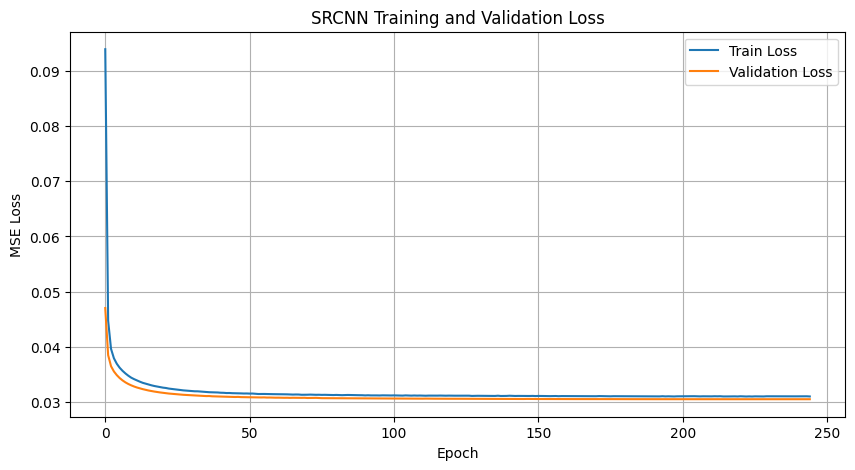

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('SRCNN Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [9]:
model = MODEL_CLASS(upsample_factor=factor)
weights, _ = load_results(model_name, factor)
model.load_state_dict(weights)
model.to(device)

FSRCA(
  (extract): Sequential(
    (0): Conv2d(1, 56, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): PReLU(num_parameters=56)
  )
  (shrink): Sequential(
    (0): Conv2d(56, 12, kernel_size=(1, 1), stride=(1, 1))
    (1): PReLU(num_parameters=12)
  )
  (mapping): RIR(
    (blocks): Sequential(
      (0): RCAB(
        (body): Sequential(
          (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (3): CALayer(
            (avg_pool): AdaptiveAvgPool2d(output_size=1)
            (channel_att): Sequential(
              (0): Conv2d(12, 1, kernel_size=(1, 1), stride=(1, 1))
              (1): ReLU(inplace=True)
              (2): Conv2d(1, 12, kernel_size=(1, 1), stride=(1, 1))
              (3): Sigmoid()
            )
          )
        )
      )
      (1): RCAB(
        (body): Sequential(
          (0): Conv2d(12, 12, kernel_s

In [10]:
evaluate_model_on_sets(model, sets=[5, 14], factor_list=[4], device=device, show_plots=False)

Set 5, Factor 4 - Average PSNR: 28.45 dB, SSIM: 0.8062
Set 14, Factor 4 - Average PSNR: 25.71 dB, SSIM: 0.7021


### Fine Tuning

In [3]:
ft_model = MODEL_CLASS(upsample_factor=factor)
weights, _ = load_results(model_name, factor)
ft_model.load_state_dict(weights)

train_loader, val_loader = get_dataloaders(factor, n_workers_train=0, n_workers_val=0, dataset="General100")

In [4]:
ft_train_loss, ft_val_loss, ft_psnr_list = train_model(ft_model, train_loader, val_loader, factor, num_epochs=ft_epochs, lr=ft_lr, criterion=criterion)
save_results(ft_model, ft_train_loss, ft_val_loss, ft_psnr_list, model_name, factor, ft=True)

Epoch 1/1000 - Training: 100%|██████████| 86/86 [01:03<00:00,  1.36it/s]


[Epoch 1] Train Loss: 0.029471
[Epoch 1] Validation Loss: 0.035690, PSNR: 26.65


Epoch 2/1000 - Training: 100%|██████████| 86/86 [00:29<00:00,  2.96it/s]


[Epoch 2] Train Loss: 0.028111
[Epoch 2] Validation Loss: 0.035599, PSNR: 26.66


Epoch 3/1000 - Training: 100%|██████████| 86/86 [00:28<00:00,  3.02it/s]


...

[Epoch 359] Train Loss: 0.026398
[Epoch 359] Validation Loss: 0.033997, PSNR: 27.02
No improvement for 8 epochs.


Epoch 360/1000 - Training: 100%|██████████| 86/86 [00:28<00:00,  3.06it/s]


[Epoch 360] Train Loss: 0.026397
[Epoch 360] Validation Loss: 0.033997, PSNR: 27.02
No improvement for 9 epochs.


Epoch 361/1000 - Training: 100%|██████████| 86/86 [00:28<00:00,  3.06it/s]


[Epoch 361] Train Loss: 0.026397
[Epoch 361] Validation Loss: 0.033997, PSNR: 27.02
No improvement for 10 epochs.
Early stopping triggered at epoch 361


In [5]:
ft_model = MODEL_CLASS(upsample_factor=factor)
ft_weights, _ = load_results(model_name, factor, ft=True)
ft_model.load_state_dict(ft_weights)
ft_model.to(device)

FSRCA(
  (extract): Sequential(
    (0): Conv2d(1, 56, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): PReLU(num_parameters=56)
  )
  (shrink): Sequential(
    (0): Conv2d(56, 12, kernel_size=(1, 1), stride=(1, 1))
    (1): PReLU(num_parameters=12)
  )
  (mapping): RIR(
    (blocks): Sequential(
      (0): RCAB(
        (body): Sequential(
          (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (3): CALayer(
            (avg_pool): AdaptiveAvgPool2d(output_size=1)
            (channel_att): Sequential(
              (0): Conv2d(12, 1, kernel_size=(1, 1), stride=(1, 1))
              (1): ReLU(inplace=True)
              (2): Conv2d(1, 12, kernel_size=(1, 1), stride=(1, 1))
              (3): Sigmoid()
            )
          )
        )
      )
      (1): RCAB(
        (body): Sequential(
          (0): Conv2d(12, 12, kernel_s

In [6]:
evaluate_model_on_sets(ft_model, sets=[5, 14], factor_list=[4], device=device, show_plots=False)

Set 5, Factor 4 - Average PSNR: 28.81 dB, SSIM: 0.8545
Set 14, Factor 4 - Average PSNR: 26.02 dB, SSIM: 0.7464
